In [ ]:
# Install all required libraries

!pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost shap joblib fastapi uvicorn streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 28.3 MB/s eta 0:00:00


In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Imbalanced data
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# XGBoost
from xgboost import XGBClassifier

# Explainable AI
import shap

# Save model
import joblib

# Other
import os
import warnings

warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Load dataset

df = pd.read_csv("/content/creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (21878, 31)


In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21878 entries, 0 to 21877
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    21878 non-null  int64  
 1   V1      21878 non-null  float64
 2   V2      21878 non-null  float64
 3   V3      21878 non-null  float64
 4   V4      21878 non-null  float64
 5   V5      21878 non-null  float64
 6   V6      21878 non-null  float64
 7   V7      21878 non-null  float64
 8   V8      21878 non-null  float64
 9   V9      21878 non-null  float64
 10  V10     21878 non-null  float64
 11  V11     21878 non-null  float64
 12  V12     21878 non-null  float64
 13  V13     21878 non-null  float64
 14  V14     21878 non-null  float64
 15  V15     21878 non-null  float64
 16  V16     21878 non-null  float64
 17  V17     21878 non-null  float64
 18  V18     21878 non-null  float64
 19  V19     21878 non-null  float64
 20  V20     21878 non-null  float64
 21  V21     21878 non-null  float64
 22

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,...,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21878.000000,21877.000000,21877.000000
mean,16924.271551,-0.241060,0.222124,0.737915,0.262153,-0.175227,0.087496,-0.141011,0.019339,0.562079,...,-0.043038,-0.140156,-0.037826,0.010707,0.125683,0.029305,0.011978,0.006293,71.725300,0.003931
std,11005.409549,1.880901,1.518111,1.740947,1.451072,1.414872,1.322606,1.323924,1.383927,1.277273,...,0.849611,0.644914,0.512947,0.590807,0.436855,0.524399,0.395178,0.247253,205.034501,0.062576
min,0.000000,-30.552380,-40.978852,-31.103685,-5.172595,-32.092129,-23.496714,-26.548144,-41.484823,-7.175097,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.338556,-8.567638,-3.612114,0.000000,0.000000
25%,5496.250000,-0.960913,-0.350012,0.298029,-0.649075,-0.756733,-0.660688,-0.597972,-0.169171,-0.273362,...,-0.257010,-0.564567,-0.175530,-0.331558,-0.136296,-0.339574,-0.067305,-0.010143,5.990000,0.000000
50%,18770.500000,-0.299205,0.206484,0.888730,0.222271,-0.210143,-0.176618,-0.069763,0.026032,0.515162,...,-0.109913,-0.111903,-0.048576,0.062115,0.163900,-0.042054,0.005402,0.019665,17.430000,0.000000
75%,27778.750000,1.164867,0.858497,1.520365,1.132694,0.332839,0.481047,0.447633,0.281472,1.330385,...,0.059938,0.267688,0.074156,0.399318,0.404503,0.320185,0.095819,0.077587,62.390000,0.000000
max,31907.000000,1.960497,16.713389,4.101716,11.927512,34.099309,21.393069,34.303177,20.007208,10.392889,...,22.614889,5.805795,13.876221,3.695503,5.525093,3.517346,8.254376,4.860769,7879.420000,1.000000


In [ ]:
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [ ]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values[missing_values > 0])

Missing values:
Amount    1
Class     1
dtype: int64


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 81


In [ ]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (21797, 31)


In [ ]:
class_counts = df["Class"].value_counts()

print("Transaction counts:")
print(class_counts)

Transaction counts:
Class
0.0    21710
1.0       86
Name: count, dtype: int64


In [ ]:
fraud_percentage = df["Class"].mean() * 100

print(f"Fraud transactions: {fraud_percentage:.4f}%")
print(f"Normal transactions: {100 - fraud_percentage:.4f}%")

Fraud transactions: 0.3946%
Normal transactions: 99.6054%


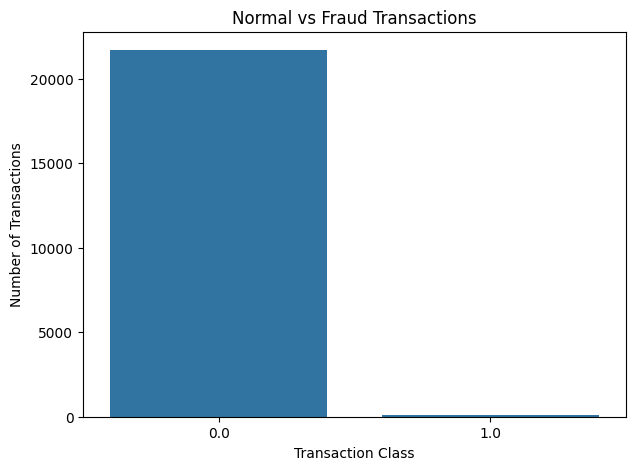

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(x="Class", data=df)

plt.title("Normal vs Fraud Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

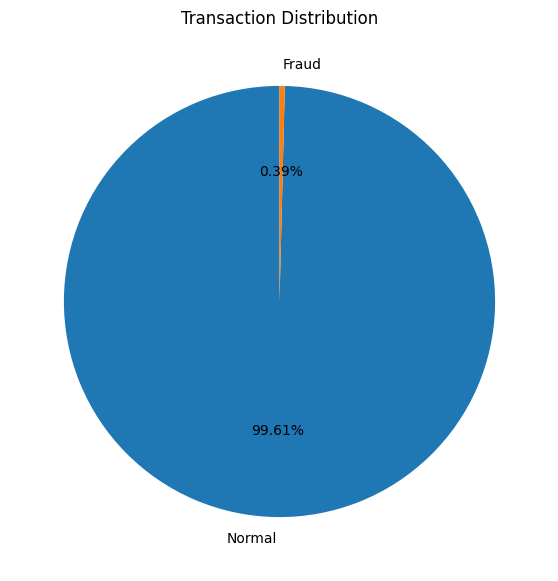

In [ ]:
labels = ["Normal", "Fraud"]
sizes = df["Class"].value_counts().sort_index()

plt.figure(figsize=(7, 7))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Transaction Distribution")

plt.show()

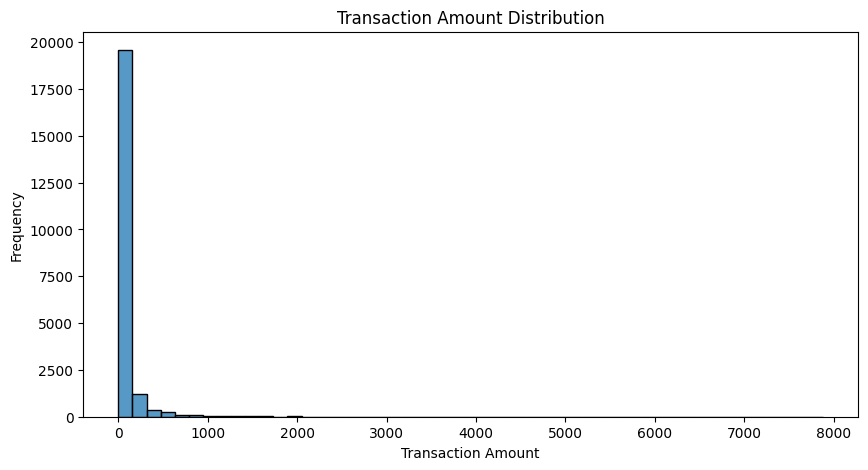

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

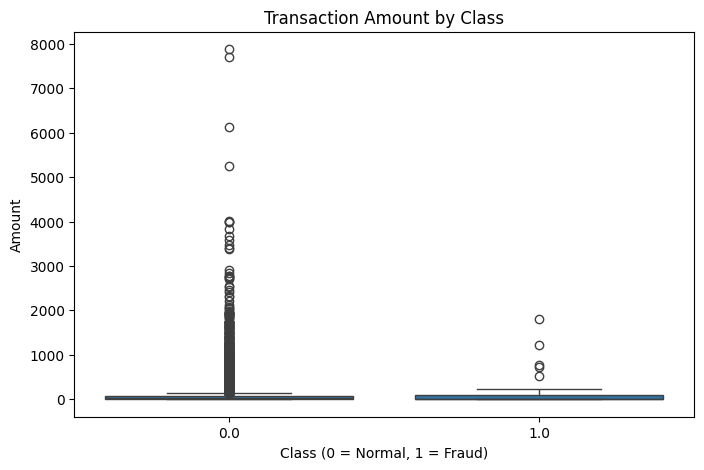

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Amount")

plt.show()

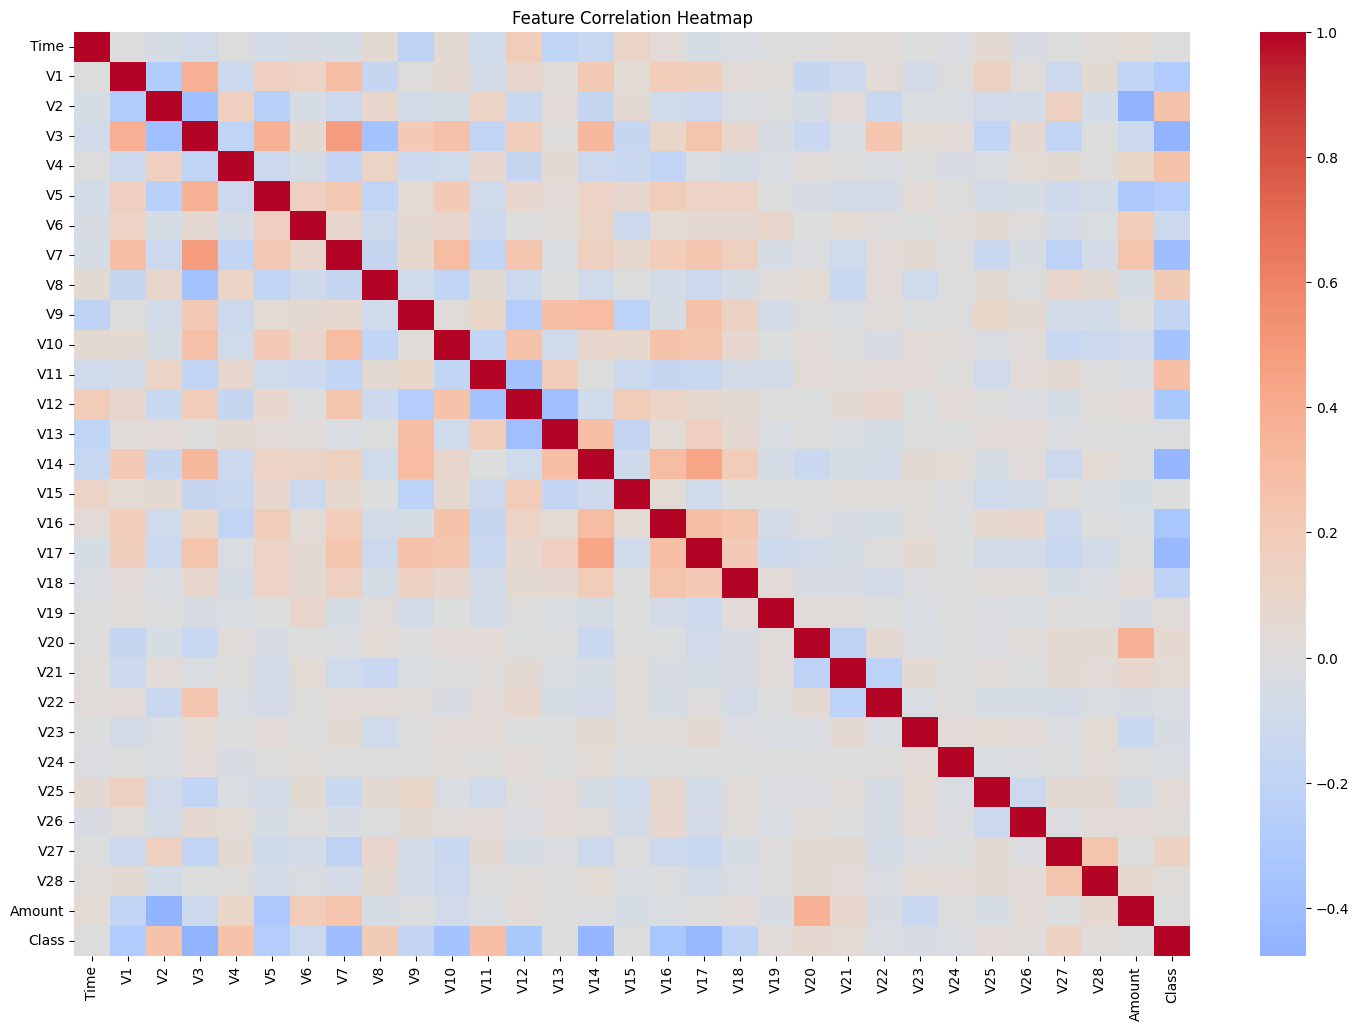

In [ ]:
plt.figure(figsize=(18, 12))

correlation = df.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [ ]:
# Separate input features and target

X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (21797, 30)
Target shape: (21797,)


In [ ]:
print("Target distribution:")
print(y.value_counts())

Target distribution:
Class
0.0    21710
1.0       86
Name: count, dtype: int64


In [ ]:
# confirm tha NaN
print(y.isna().sum())
print(df[df["Class"].isna()])

# Drop that row from both X and y
mask = y.notna()
X = X[mask]
y = y[mask]

print(X.shape, y.shape)


1
        Time        V1        V2        V3        V4        V5        V6  \
21877  31907 -0.184653  0.376693  0.632988 -2.282365  0.403553 -0.371666   

             V7        V8        V9  ...       V21       V22       V23  \
21877  0.695359 -0.064835  0.610986  ... -0.130997 -0.312833 -0.156567   

            V24       V25       V26       V27       V28  Amount  Class  
21877 -0.899683  0.093186 -0.130187  0.029255  0.009228     NaN    NaN  

[1 rows x 31 columns]
(21796, 30) (21796,)


In [ ]:
# First split: 80% training+validation, 20% test

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: 70% training, 10% validation

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,
    random_state=42,
    stratify=y_train_val
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (15256, 30)
Validation set: (2180, 30)
Test set: (4360, 30)


In [ ]:
print("Training:")
print(y_train.value_counts())

print("\nValidation:")
print(y_val.value_counts())

print("\nTest:")
print(y_test.value_counts())

Training:
Class
0.0    15196
1.0       60
Name: count, dtype: int64

Validation:
Class
0.0    2171
1.0       9
Name: count, dtype: int64

Test:
Class
0.0    4343
1.0      17
Name: count, dtype: int64


In [ ]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),

    ("smote", SMOTE(
        random_state=42
    )),

    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


In [ ]:
print("Training Logistic Regression...")

lr_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed!")

Training Logistic Regression...
Logistic Regression training completed!


In [ ]:
lr_pred = lr_pipeline.predict(X_val)

lr_probability = lr_pipeline.predict_proba(X_val)[:, 1]

print("Predictions completed.")

Predictions completed.


In [ ]:
lr_accuracy = accuracy_score(y_val, lr_pred)
lr_precision = precision_score(y_val, lr_pred)
lr_recall = recall_score(y_val, lr_pred)
lr_f1 = f1_score(y_val, lr_pred)
lr_roc_auc = roc_auc_score(y_val, lr_probability)
lr_pr_auc = average_precision_score(y_val, lr_probability)

print("Logistic Regression Results")
print("----------------------------")

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_roc_auc:.4f}")
print(f"PR-AUC   : {lr_pr_auc:.4f}")

Logistic Regression Results
----------------------------
Accuracy : 0.9917
Precision: 0.3043
Recall   : 0.7778
F1 Score : 0.4375
ROC-AUC  : 0.9207
PR-AUC   : 0.5649


In [ ]:
print(
    classification_report(
        y_val,
        lr_pred,
        target_names=["Normal", "Fraud"]
    )
)

              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00      2171
       Fraud       0.30      0.78      0.44         9

    accuracy                           0.99      2180
   macro avg       0.65      0.89      0.72      2180
weighted avg       1.00      0.99      0.99      2180



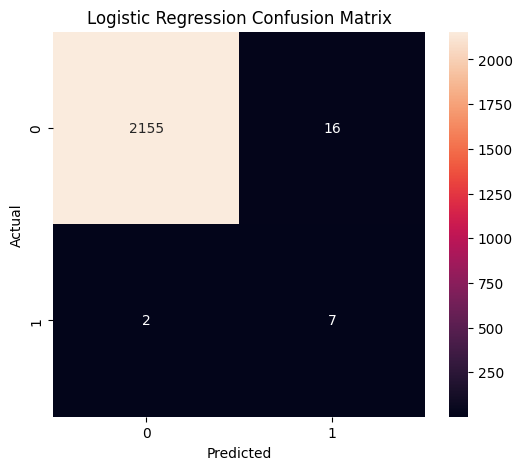

In [ ]:
cm = confusion_matrix(y_val, lr_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),

    ("smote", SMOTE(
        random_state=42
    )),

    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [ ]:
print("Training Random Forest...")

rf_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


In [ ]:
rf_pred = rf_pipeline.predict(X_val)

rf_probability = rf_pipeline.predict_proba(X_val)[:, 1]

print("Predictions completed.")

Predictions completed.


In [ ]:
rf_accuracy = accuracy_score(y_val, rf_pred)
rf_precision = precision_score(y_val, rf_pred)
rf_recall = recall_score(y_val, rf_pred)
rf_f1 = f1_score(y_val, rf_pred)
rf_roc_auc = roc_auc_score(y_val, rf_probability)
rf_pr_auc = average_precision_score(y_val, rf_probability)

print("Random Forest Results")
print("---------------------")

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")
print(f"PR-AUC   : {rf_pr_auc:.4f}")

Random Forest Results
---------------------
Accuracy : 0.9986
Precision: 0.8750
Recall   : 0.7778
F1 Score : 0.8235
ROC-AUC  : 0.9999
PR-AUC   : 0.9675


In [ ]:
print(
    classification_report(
        y_val,
        rf_pred,
        target_names=["Normal", "Fraud"]
    )
)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2171
       Fraud       0.88      0.78      0.82         9

    accuracy                           1.00      2180
   macro avg       0.94      0.89      0.91      2180
weighted avg       1.00      1.00      1.00      2180



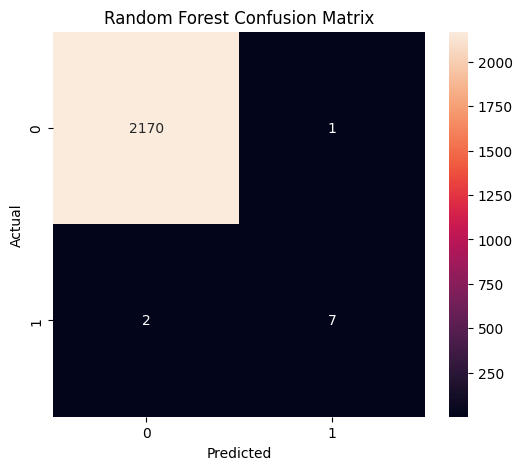

In [ ]:
cm = confusion_matrix(y_val, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
xgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),

    ("smote", SMOTE(
        random_state=42
    )),

    ("model", XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

print("XGBoost pipeline created.")

XGBoost pipeline created.


In [ ]:
print("Training XGBoost...")

xgb_pipeline.fit(
    X_train,
    y_train
)

print("XGBoost training completed!")

Training XGBoost...
XGBoost training completed!


In [ ]:
xgb_pred = xgb_pipeline.predict(X_val)

xgb_probability = xgb_pipeline.predict_proba(X_val)[:, 1]

print("XGBoost predictions completed.")

XGBoost predictions completed.


In [ ]:
xgb_accuracy = accuracy_score(y_val, xgb_pred)
xgb_precision = precision_score(y_val, xgb_pred)
xgb_recall = recall_score(y_val, xgb_pred)
xgb_f1 = f1_score(y_val, xgb_pred)
xgb_roc_auc = roc_auc_score(y_val, xgb_probability)
xgb_pr_auc = average_precision_score(y_val, xgb_probability)

print("XGBoost Results")
print("----------------")

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_pr_auc:.4f}")

XGBoost Results
----------------
Accuracy : 0.9986
Precision: 0.8000
Recall   : 0.8889
F1 Score : 0.8421
ROC-AUC  : 0.9998
PR-AUC   : 0.9576


In [ ]:
print(
    classification_report(
        y_val,
        xgb_pred,
        target_names=["Normal", "Fraud"]
    )
)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2171
       Fraud       0.80      0.89      0.84         9

    accuracy                           1.00      2180
   macro avg       0.90      0.94      0.92      2180
weighted avg       1.00      1.00      1.00      2180



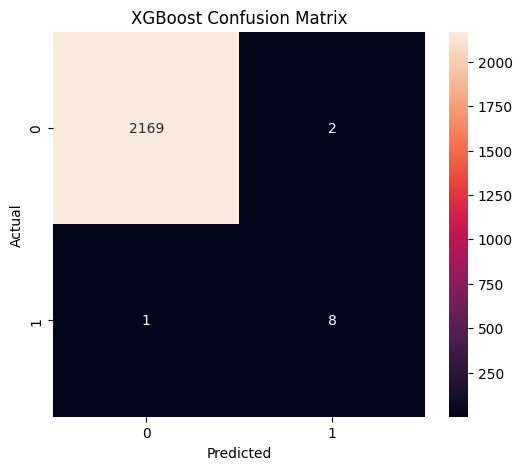

In [ ]:
cm = confusion_matrix(y_val, xgb_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        lr_precision,
        rf_precision,
        xgb_precision
    ],

    "Recall": [
        lr_recall,
        rf_recall,
        xgb_recall
    ],

    "F1 Score": [
        lr_f1,
        rf_f1,
        xgb_f1
    ],

    "ROC-AUC": [
        lr_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ],

    "PR-AUC": [
        lr_pr_auc,
        rf_pr_auc,
        xgb_pr_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.991743,0.304348,0.777778,0.437500,0.920671,0.564882
1,Random Forest,0.998624,0.875000,0.777778,0.823529,0.999872,0.967452
2,XGBoost,0.998624,0.800000,0.888889,0.842105,0.999795,0.957576


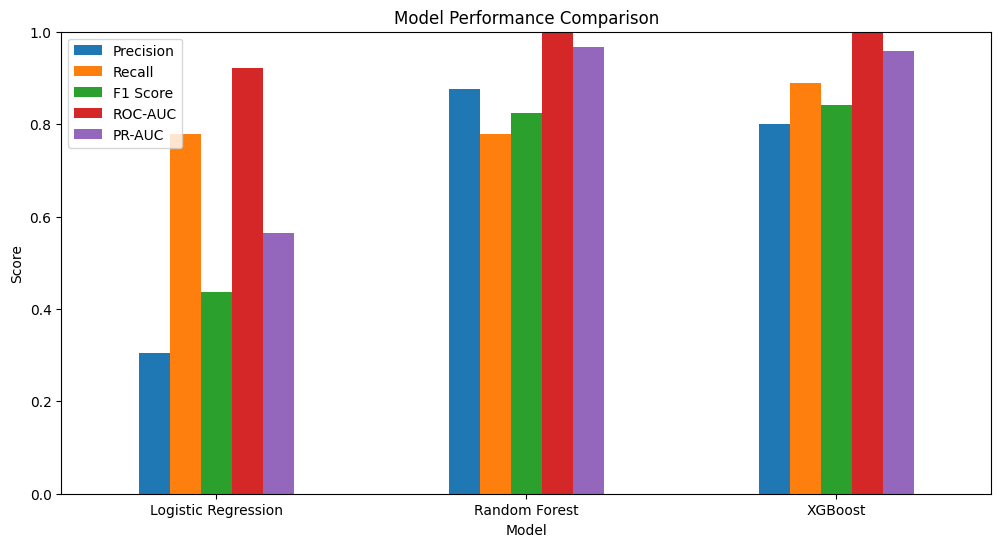

In [ ]:
results_plot = results.set_index("Model")

results_plot[[
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC"
]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.show()

In [ ]:
xgb_tuning_pipeline = Pipeline([
    ("scaler", StandardScaler()),

    ("smote", SMOTE(
        random_state=42
    )),

    ("model", XGBClassifier(
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

print("Hyperparameter grid created.")

Hyperparameter grid created.


In [ ]:
random_search = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline,
    param_distributions=param_grid,
    n_iter=5,
    scoring="average_precision",
    cv=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter tuning...")

random_search.fit(
    X_train,
    y_train
)

print("Hyperparameter tuning completed!")

Starting hyperparameter tuning...
Fitting 2 folds for each of 5 candidates, totalling 10 fits
Hyperparameter tuning completed!


In [ ]:
print("Best parameters:")

for parameter, value in random_search.best_params_.items():
    print(parameter, "=", value)

Best parameters:
model__subsample = 1.0
model__n_estimators = 200
model__max_depth = 3
model__learning_rate = 0.05
model__colsample_bytree = 1.0


In [ ]:
print(
    "Best Cross-Validation PR-AUC:",
    random_search.best_score_
)

Best Cross-Validation PR-AUC: 0.9060655103325228


In [ ]:
best_xgb_model = random_search.best_estimator_

print("Best XGBoost model selected.")

Best XGBoost model selected.


In [ ]:
tuned_val_probability = best_xgb_model.predict_proba(X_val)[:, 1]

tuned_val_pred = (
    tuned_val_probability >= 0.5
).astype(int)

print("Validation predictions generated.")

Validation predictions generated.


In [ ]:
print("Tuned XGBoost Results")
print("---------------------")

print(
    f"Accuracy : {accuracy_score(y_val, tuned_val_pred):.4f}"
)

print(
    f"Precision: {precision_score(y_val, tuned_val_pred):.4f}"
)

print(
    f"Recall   : {recall_score(y_val, tuned_val_pred):.4f}"
)

print(
    f"F1 Score : {f1_score(y_val, tuned_val_pred):.4f}"
)

print(
    f"ROC-AUC  : {roc_auc_score(y_val, tuned_val_probability):.4f}"
)

print(
    f"PR-AUC   : {average_precision_score(y_val, tuned_val_probability):.4f}"
)

Tuned XGBoost Results
---------------------
Accuracy : 0.9986
Precision: 0.8000
Recall   : 0.8889
F1 Score : 0.8421
ROC-AUC  : 0.9996
PR-AUC   : 0.9333


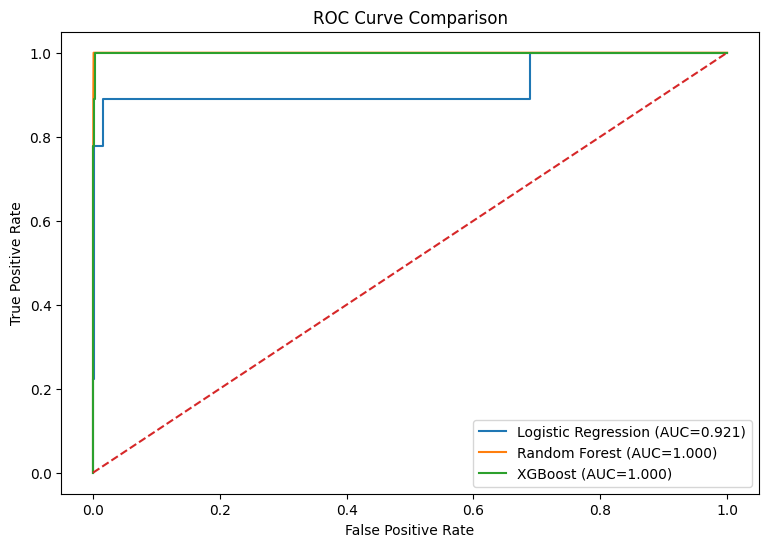

In [ ]:
lr_fpr, lr_tpr, _ = roc_curve(
    y_val,
    lr_probability
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_val,
    rf_probability
)

xgb_fpr, xgb_tpr, _ = roc_curve(
    y_val,
    tuned_val_probability
)

plt.figure(figsize=(9, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={lr_roc_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={rf_roc_auc:.3f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC={roc_auc_score(y_val, tuned_val_probability):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

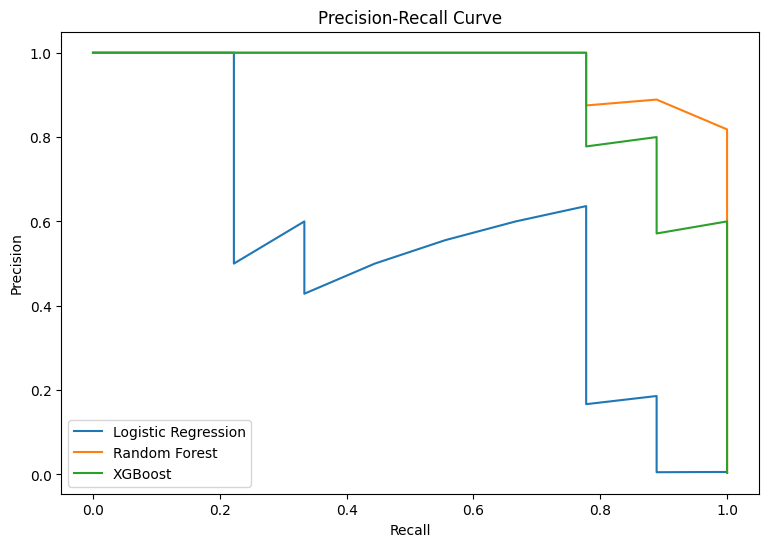

In [ ]:
lr_precision_curve, lr_recall_curve, _ = precision_recall_curve(
    y_val,
    lr_probability
)

rf_precision_curve, rf_recall_curve, _ = precision_recall_curve(
    y_val,
    rf_probability
)

xgb_precision_curve, xgb_recall_curve, _ = precision_recall_curve(
    y_val,
    tuned_val_probability
)

plt.figure(figsize=(9, 6))

plt.plot(
    lr_recall_curve,
    lr_precision_curve,
    label="Logistic Regression"
)

plt.plot(
    rf_recall_curve,
    rf_precision_curve,
    label="Random Forest"
)

plt.plot(
    xgb_recall_curve,
    xgb_precision_curve,
    label="XGBoost"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

In [ ]:
threshold_results = []

thresholds = np.arange(
    0.01,
    1.00,
    0.01
)

for threshold in thresholds:

    predictions = (
        tuned_val_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        predictions
    ).ravel()

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    fpr = fp / (fp + tn)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "False Positive Rate": fpr
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.head()

,Threshold,Precision,Recall,F1 Score,False Positive Rate
0,0.01,0.310345,1.0,0.473684,0.009212
1,0.02,0.473684,1.0,0.642857,0.004606
2,0.03,0.562500,1.0,0.720000,0.003224
3,0.04,0.562500,1.0,0.720000,0.003224
4,0.05,0.562500,1.0,0.720000,0.003224


In [ ]:
valid_thresholds = threshold_df[
    (threshold_df["Recall"] >= 0.80) &
    (threshold_df["False Positive Rate"] <= 0.05)
]

if len(valid_thresholds) > 0:

    best_threshold_row = valid_thresholds.sort_values(
        by="F1 Score",
        ascending=False
    ).iloc[0]

    best_threshold = best_threshold_row["Threshold"]

    print("Threshold meeting the target requirements found.")

else:

    best_threshold_row = threshold_df.sort_values(
        by="F1 Score",
        ascending=False
    ).iloc[0]

    best_threshold = best_threshold_row["Threshold"]

    print(
        "No threshold met both targets, so the best F1 threshold was selected."
    )

print("Selected threshold:", best_threshold)

Threshold meeting the target requirements found.
Selected threshold: 0.65


In [ ]:
print(
    best_threshold_row
)

Threshold              0.650000
Precision              0.800000
Recall                 0.888889
F1 Score               0.842105
False Positive Rate    0.000921
Name: 64, dtype: float64


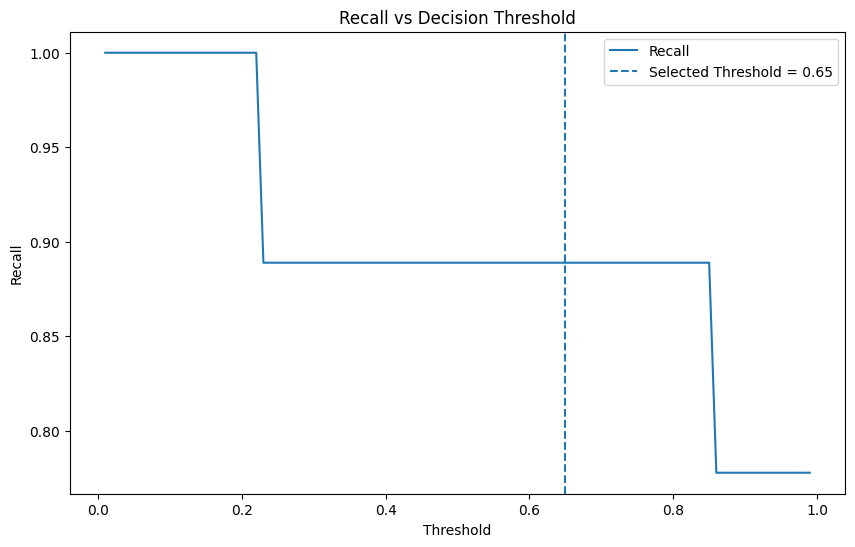

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Selected Threshold = {best_threshold:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Recall")

plt.title("Recall vs Decision Threshold")

plt.legend()

plt.show()

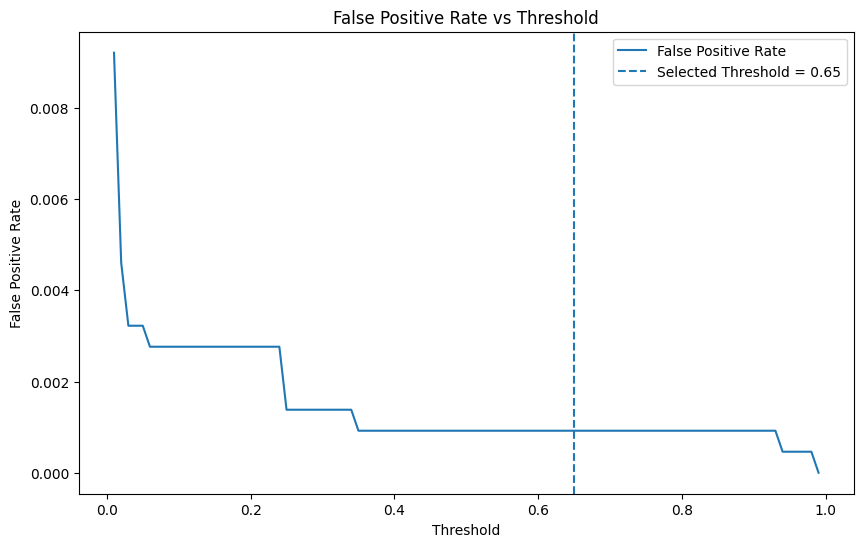

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["False Positive Rate"],
    label="False Positive Rate"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Selected Threshold = {best_threshold:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("False Positive Rate")

plt.title("False Positive Rate vs Threshold")

plt.legend()

plt.show()

In [ ]:
optimized_val_pred = (
    tuned_val_probability >= best_threshold
).astype(int)

print(
    classification_report(
        y_val,
        optimized_val_pred,
        target_names=["Normal", "Fraud"]
    )
)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2171
       Fraud       0.80      0.89      0.84         9

    accuracy                           1.00      2180
   macro avg       0.90      0.94      0.92      2180
weighted avg       1.00      1.00      1.00      2180



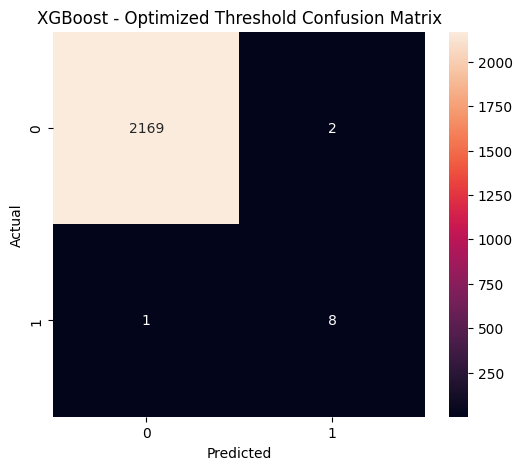

In [ ]:
cm = confusion_matrix(
    y_val,
    optimized_val_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "XGBoost - Optimized Threshold Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
tn, fp, fn, tp = confusion_matrix(
    y_val,
    optimized_val_pred
).ravel()

false_positive_rate = fp / (fp + tn)

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print(
    f"\nFalse Positive Rate: {false_positive_rate:.4%}"
)

print(
    f"Fraud Recall: {recall_score(y_val, optimized_val_pred):.4%}"
)

True Negatives : 2169
False Positives: 2
False Negatives: 1
True Positives : 8

False Positive Rate: 0.0921%
Fraud Recall: 88.8889%


In [ ]:
# Get the actual XGBoost model from the pipeline

xgb_model = best_xgb_model.named_steps["model"]

scaler = best_xgb_model.named_steps["scaler"]

print("XGBoost model extracted.")

XGBoost model extracted.


In [ ]:
# Transform validation data using the same scaler

X_val_scaled = scaler.transform(X_val)

# Use a smaller sample for SHAP to keep computation fast

sample_size = min(1000, X_val_scaled.shape[0])

X_shap = X_val_scaled[:sample_size]

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (1000, 30)


In [ ]:
explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(
    X_shap
)

print("SHAP values calculated!")

SHAP values calculated!


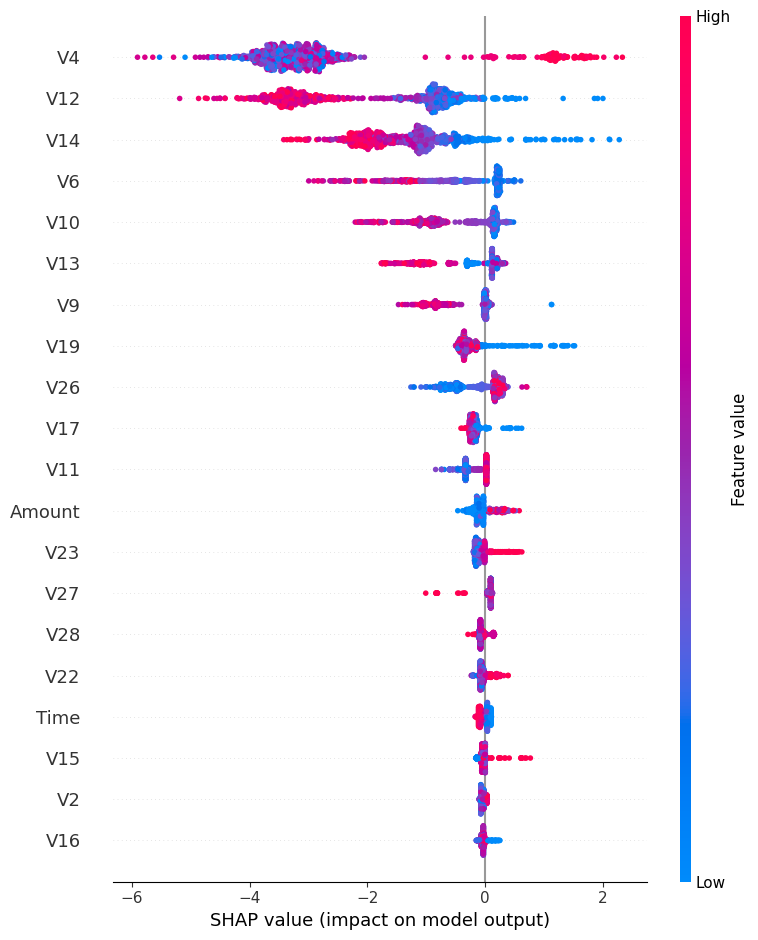

In [ ]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X.columns
)

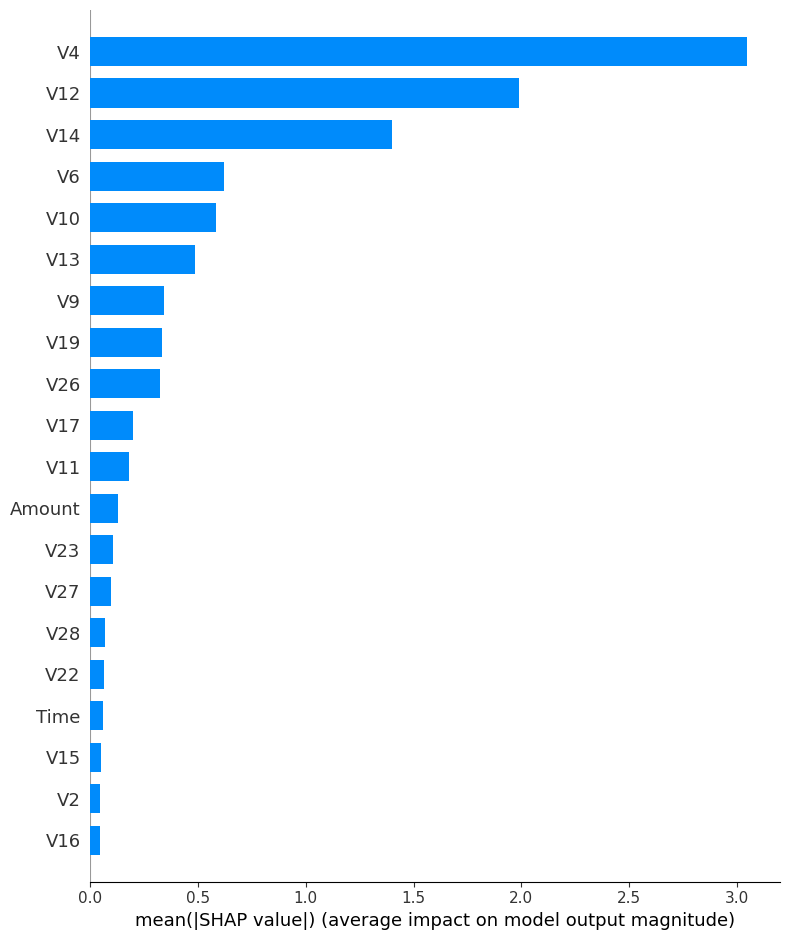

In [ ]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X.columns,
    plot_type="bar"
)

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
14,V14,0.605126
12,V12,0.100358
4,V4,0.094198
10,V10,0.050048
19,V19,0.026365
6,V6,0.019655
7,V7,0.016540
22,V22,0.011470
5,V5,0.010163
8,V8,0.009195


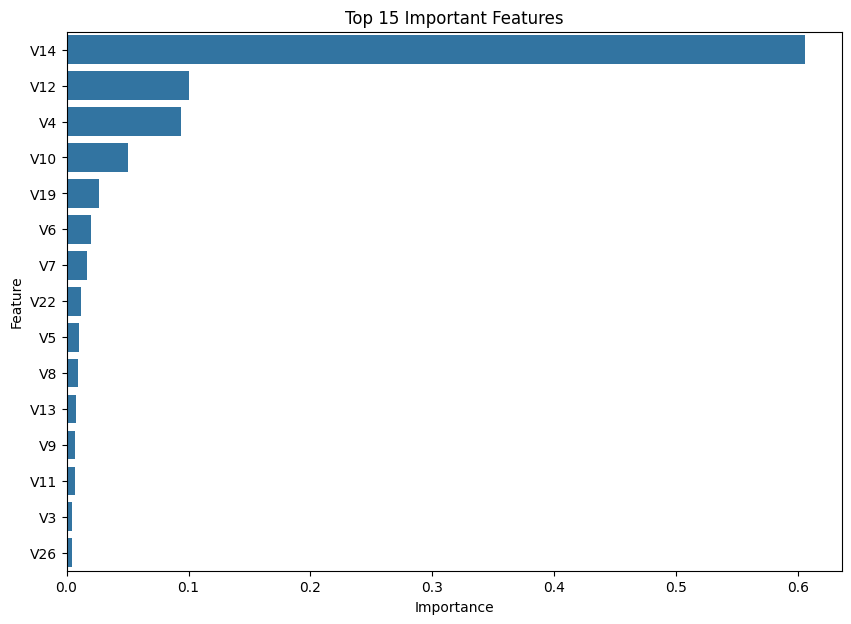

In [ ]:
plt.figure(figsize=(10, 7))

top_features = feature_importance.head(15)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

In [ ]:
test_probability = best_xgb_model.predict_proba(
    X_test
)[:, 1]

print("Test probabilities generated.")

Test probabilities generated.


In [ ]:
test_pred = (
    test_probability >= best_threshold
).astype(int)

print("Final test predictions generated.")

Final test predictions generated.


In [ ]:
final_accuracy = accuracy_score(
    y_test,
    test_pred
)

final_precision = precision_score(
    y_test,
    test_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    test_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    test_pred,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    test_probability
)

final_pr_auc = average_precision_score(
    y_test,
    test_probability
)

print("========== FINAL TEST RESULTS ==========")

print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_roc_auc:.4f}")
print(f"PR-AUC   : {final_pr_auc:.4f}")

========== FINAL TEST RESULTS ==========
Accuracy : 0.9986
Precision: 0.7895
Recall   : 0.8824
F1 Score : 0.8333
ROC-AUC  : 0.9987
PR-AUC   : 0.9113


In [ ]:
print(
    classification_report(
        y_test,
        test_pred,
        target_names=["Normal", "Fraud"]
    )
)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      4343
       Fraud       0.79      0.88      0.83        17

    accuracy                           1.00      4360
   macro avg       0.89      0.94      0.92      4360
weighted avg       1.00      1.00      1.00      4360



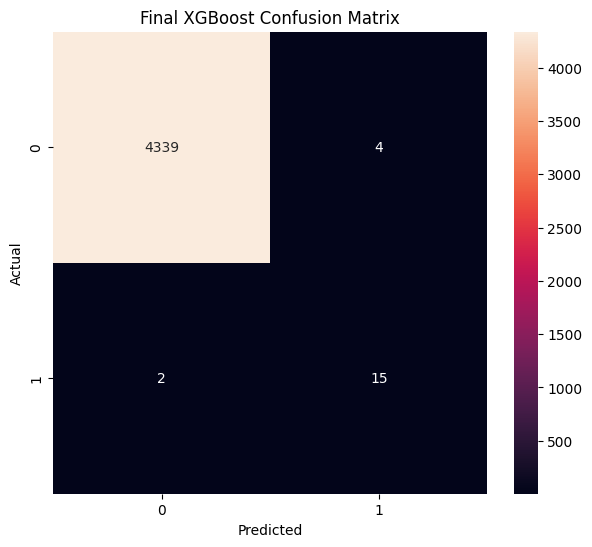

In [ ]:
cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Final XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
tn, fp, fn, tp = cm.ravel()

final_fpr = fp / (fp + tn)

print("Final Test Performance")
print("----------------------")

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print(f"\nFraud Recall       : {final_recall:.2%}")
print(f"False Positive Rate: {final_fpr:.2%}")

Final Test Performance
----------------------
True Negatives : 4339
False Positives: 4
False Negatives: 2
True Positives : 15

Fraud Recall       : 88.24%
False Positive Rate: 0.09%


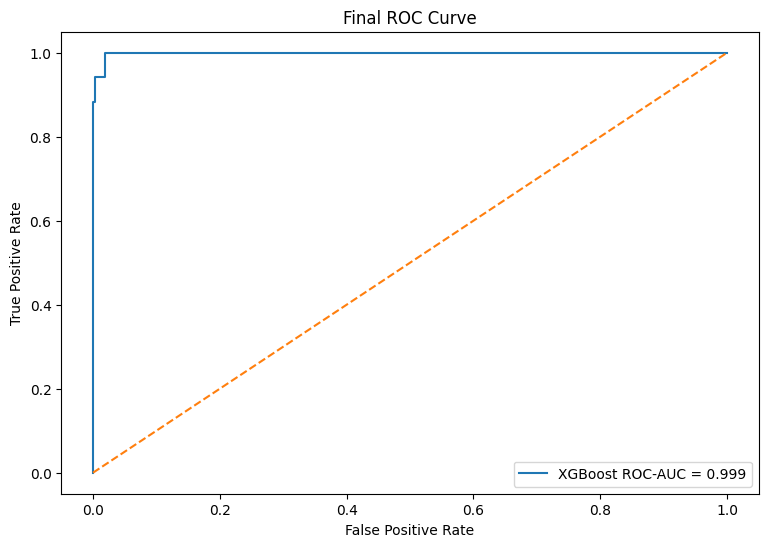

In [ ]:
fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    test_probability
)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost ROC-AUC = {final_roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Final ROC Curve")

plt.legend()

plt.show()

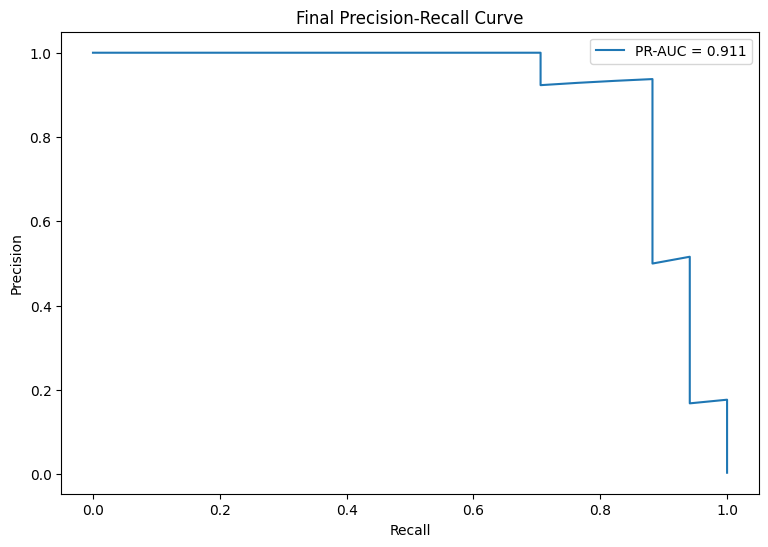

In [ ]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    test_probability
)

plt.figure(figsize=(9, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {final_pr_auc:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Final Precision-Recall Curve")

plt.legend()

plt.show()

In [ ]:
model_artifact = {
    "model": best_xgb_model,
    "threshold": float(best_threshold),
    "features": X.columns.tolist()
}

joblib.dump(
    model_artifact,
    "fraud_detection_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

print(
    "Model file size:",
    round(
        os.path.getsize("fraud_detection_model.pkl") / (1024 * 1024),
        2
    ),
    "MB"
)

Model file size: 0.23 MB


In [ ]:
from google.colab import files

files.download(
    "fraud_detection_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
sample_transaction = X_test.iloc[[0]]

print(sample_transaction)

        Time        V1        V2        V3        V4        V5       V6  \
11686  19940 -4.307673  3.071724 -3.097641  1.464154 -2.647874 -1.60243   

             V7        V8        V9  ...       V20       V21       V22  \
11686 -1.204864  2.576829  0.787941  ... -0.119579  0.055496  0.122756   

            V23      V24       V25       V26      V27       V28  Amount  
11686 -0.010604  0.68188 -0.427172 -0.450865  0.28593 -0.011215   89.99  

[1 rows x 30 columns]


In [ ]:
probability = best_xgb_model.predict_proba(
    sample_transaction
)[0, 1]

prediction = int(
    probability >= best_threshold
)

print("Fraud Probability:", f"{probability:.4%}")

if prediction == 1:
    print("Prediction: FRAUD")
else:
    print("Prediction: NORMAL")

Fraud Probability: 0.0075%
Prediction: NORMAL


In [ ]:
def predict_fraud(transaction_data):

    probability = best_xgb_model.predict_proba(
        transaction_data
    )[0, 1]

    prediction = int(
        probability >= best_threshold
    )

    if prediction == 1:
        result = "FRAUD"
    else:
        result = "NORMAL"

    return result, probability

In [ ]:
result, probability = predict_fraud(
    sample_transaction
)

print("Prediction:", result)
print("Fraud Probability:", f"{probability:.4%}")

Prediction: NORMAL
Fraud Probability: 0.0075%


In [ ]:
sample_transaction.to_csv(
    "sample_transaction.csv",
    index=False
)

print("Sample transaction saved.")

Sample transaction saved.


In [ ]:
requirements = """
pandas
numpy
matplotlib
seaborn
scikit-learn
imbalanced-learn
xgboost
shap
joblib
streamlit
fastapi
uvicorn
"""

with open(
    "requirements.txt",
    "w"
) as file:
    file.write(requirements.strip())

print("requirements.txt created.")

requirements.txt created.


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# -----------------------------
# Load Model
# -----------------------------

artifact = joblib.load(
    "fraud_detection_model.pkl"
)

model = artifact["model"]
threshold = artifact["threshold"]
features = artifact["features"]


# -----------------------------
# Page Configuration
# -----------------------------

st.set_page_config(
    page_title="Bank Fraud Detection",
    page_icon="💳",
    layout="wide"
)


# -----------------------------
# Title
# -----------------------------

st.title("💳 Bank Fraud Detection System")

st.write(
    "Machine Learning based fraud detection using XGBoost."
)

st.info(
    f"Fraud decision threshold: {threshold:.2f}"
)


# -----------------------------
# Input Method
# -----------------------------

st.subheader("Enter Transaction Details")

transaction_data = {}

for feature in features:

    transaction_data[feature] = st.number_input(
        feature,
        value=0.0,
        format="%.6f"
    )


# -----------------------------
# Prediction
# -----------------------------

if st.button("🔍 Check Transaction"):

    input_df = pd.DataFrame(
        [transaction_data]
    )

    probability = model.predict_proba(
        input_df
    )[0, 1]

    prediction = int(
        probability >= threshold
    )

    st.subheader("Prediction Result")

    st.metric(
        "Fraud Probability",
        f"{probability:.2%}"
    )

    if prediction == 1:

        st.error(
            "🚨 FRAUDULENT TRANSACTION DETECTED"
        )

    else:

        st.success(
            "✅ TRANSACTION APPEARS NORMAL"
        )

    st.write(
        "The prediction is based on the trained XGBoost model."
    )

Writing app.py


In [ ]:
!ls -lh app.py fraud_detection_model.pkl requirements.txt

-rw-r--r-- 1 root root 1.7K Sep  6 05:41 app.py
-rw-r--r-- 1 root root 236K Sep  6 05:36 fraud_detection_model.pkl
-rw-r--r-- 1 root root  107 Sep  6 05:41 requirements.txt


In [ ]:
!streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [ ]:
!./cloudflared tunnel --url http://localhost:8501 --no-autoupdate > tunnel.log 2>&1 &

In [ ]:
import time
import re

time.sleep(5)

with open("tunnel.log", "r") as f:
    log = f.read()

urls = re.findall(
    r"https://[a-zA-Z0-9\-]+\.trycloudflare\.com",
    log
)

print("Streamlit URL:")
print(urls[0] if urls else "URL not found. Check tunnel.log")

Streamlit URL:
https://audience-requested-commissioner-declare.trycloudflare.com


In [ ]:
%%writefile api.py

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import pandas as pd
import joblib


# -----------------------------
# Load Model
# -----------------------------

artifact = joblib.load(
    "fraud_detection_model.pkl"
)

model = artifact["model"]
threshold = artifact["threshold"]
features = artifact["features"]


# -----------------------------
# Create FastAPI App
# -----------------------------

app = FastAPI(
    title="Bank Fraud Detection API",
    description="Machine Learning API for detecting fraudulent transactions",
    version="1.0"
)


# -----------------------------
# Request Model
# -----------------------------

class TransactionRequest(BaseModel):

    data: dict[str, float]


# -----------------------------
# Home Endpoint
# -----------------------------

@app.get("/")
def home():

    return {
        "message": "Bank Fraud Detection API is running",
        "status": "success"
    }


# -----------------------------
# Prediction Endpoint
# -----------------------------

@app.post("/predict")
def predict(request: TransactionRequest):

    received_features = set(
        request.data.keys()
    )

    expected_features = set(
        features
    )

    missing_features = expected_features - received_features

    if missing_features:

        raise HTTPException(
            status_code=400,
            detail={
                "message": "Missing features",
                "missing_features": list(
                    missing_features
                )
            }
        )

    # Arrange features in correct order

    input_data = pd.DataFrame(
        [[request.data[feature] for feature in features]],
        columns=features
    )

    probability = model.predict_proba(
        input_data
    )[0, 1]

    prediction = int(
        probability >= threshold
    )

    if prediction == 1:
        result = "FRAUD"
    else:
        result = "NORMAL"

    return {
        "prediction": result,
        "fraud_probability": float(probability),
        "threshold": float(threshold)
    }

Writing api.py


In [ ]:
!uvicorn api:app --host 0.0.0.0 --port 8000 > api.log 2>&1 &

In [ ]:
import requests

response = requests.get(
    "http://127.0.0.1:8000/"
)

print(response.json())

{'message': 'Bank Fraud Detection API is running', 'status': 'success'}


In [ ]:
sample_values = X_test.iloc[0].to_dict()

sample_values

{'Time': 19940.0,
 'V1': -4.30767332616671,
 'V2': 3.07172392802953,
 'V3': -3.09764129513254,
 'V4': 1.46415446409305,
 'V5': -2.64787437560219,
 'V6': -1.6024295361472,
 'V7': -1.20486402385711,
 'V8': 2.57682850386338,
 'V9': 0.787940614469718,
 'V10': 0.0430106055474565,
 'V11': -0.220386558626016,
 'V12': -1.45376001473664,
 'V13': 1.67605977785392,
 'V14': 3.84023960002632,
 'V15': -0.133869455232824,
 'V16': 0.200663782668458,
 'V17': 1.83249232964687,
 'V18': 0.250069348181844,
 'V19': -0.180539057884531,
 'V20': -0.119578928377086,
 'V21': 0.0554959944839451,
 'V22': 0.122755595782712,
 'V23': -0.0106035634462456,
 'V24': 0.681879670216074,
 'V25': -0.427172190023637,
 'V26': -0.450865430243828,
 'V27': 0.285930346285501,
 'V28': -0.0112149493745972,
 'Amount': 89.99}

In [ ]:
api_response = requests.post(
    "http://127.0.0.1:8000/predict",
    json={
        "data": sample_values
    }
)

print(api_response.json())

{'prediction': 'NORMAL', 'fraud_probability': 7.538164936704561e-05, 'threshold': 0.65}


In [ ]:
import os

print("Project files:")

for file in os.listdir("."):
    if file.endswith(
        (
            ".py",
            ".pkl",
            ".txt",
            ".csv"
        )
    ):
        print(file)

Project files:
fraud_detection_model.pkl
creditcard.csv
requirements.txt
sample_transaction.csv
api.py
app.py


In [ ]:
readme = """
# Bank Fraud Detection using Machine Learning

## Project Overview

This project develops a machine learning system to identify fraudulent credit card transactions.

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- SMOTE
- Random Forest
- XGBoost
- SHAP
- Streamlit
- FastAPI

## Machine Learning Workflow

1. Data Loading
2. Exploratory Data Analysis
3. Data Preprocessing
4. Train/Validation/Test Split
5. Handling Class Imbalance using SMOTE
6. Logistic Regression
7. Random Forest
8. XGBoost
9. Hyperparameter Tuning
10. Model Evaluation
11. Threshold Optimization
12. SHAP Explainability
13. Model Saving
14. Streamlit Deployment
15. FastAPI Deployment

## Dataset

Credit Card Fraud Detection dataset.

The target variable is:

- 0 = Normal transaction
- 1 = Fraudulent transaction

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- PR-AUC
- False Positive Rate

## Explainability

SHAP is used to understand which features influence fraud predictions.

## Application

A Streamlit interface is provided for interactive fraud prediction.

A FastAPI backend is provided for API-based fraud prediction.

## Author

Your Name
"""

with open(
    "README.md",
    "w"
) as file:
    file.write(readme.strip())

print("README.md created!")

README.md created!


In [ ]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC",
        "False Positive Rate",
        "Decision Threshold"
    ],

    "Value": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc,
        final_pr_auc,
        final_fpr,
        best_threshold
    ]
})

final_results

,Metric,Value
0,Accuracy,0.998624
1,Precision,0.789474
2,Recall,0.882353
3,F1 Score,0.833333
4,ROC-AUC,0.998686
5,PR-AUC,0.911330
6,False Positive Rate,0.000921
7,Decision Threshold,0.650000


In [ ]:
final_results.to_csv(
    "final_results.csv",
    index=False
)

print("Final results saved.")

Final results saved.


In [ ]:
from google.colab import files

files.download("fraud_detection_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("api.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("final_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>